# Customer Segmentation Analysis 

This project performs customer segmentation analysis for an e-commerce company. By analyzing customer behavior and purchase patterns, we group customers into distinct segments to inform targeted marketing strategies, improve customer satisfaction, and enhance overall business strategies.

## 1. Data Loading and Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_csv('ifood_df.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (2205, 39)

First 5 rows:


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [3]:
print('Dataset Info:')
print(df.info())
print(f'\n\nMissing values per column:{df.isnull().sum().max()}')
print(f'\nNumber of duplicate rows: {df.duplicated().sum()}')

# Drop constant columns (Z_CostContact, Z_Revenue - identical values)
df.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)
print('\nDropped Z_CostContact and Z_Revenue (constant columns)')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  Accepte

## 2. Feature Engineering

Creating derived features to better capture customer behavior.

In [4]:
# Create derived features
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
df['HasChildren'] = (df['TotalChildren'] > 0).astype(int)
df['AvgSpendPerPurchase'] = df['MntTotal'] / (df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + 1)
df['TotalPurchases'] = df['NumDealsPurchases'] + df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

# Marital status mapping
marital_cols = ['marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow']
df['MaritalStatus'] = df[marital_cols].idxmax(axis=1).str.replace('marital_', '')

# Education mapping
edu_cols = ['education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD']
df['EducationLevel'] = df[edu_cols].idxmax(axis=1).str.replace('education_', '')

df[['Income', 'MntTotal', 'TotalChildren', 'MaritalStatus', 'EducationLevel', 'TotalPurchases', 'AvgSpendPerPurchase']].head()

,Income,MntTotal,TotalChildren,MaritalStatus,EducationLevel,TotalPurchases,AvgSpendPerPurchase
0,58138.0,1529,0,Single,Graduation,25,66.478261
1,46344.0,21,2,Single,Graduation,6,4.200000
2,71613.0,734,0,Together,Graduation,21,34.952381
3,26646.0,48,1,Together,Graduation,8,6.857143
4,58293.0,407,1,Married,PhD,19,27.133333


## 3. Descriptive Statistics

In [5]:
print('Descriptive Statistics for key metrics:')
display(df[['Income', 'Recency', 'MntTotal', 'MntRegularProds', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth', 'TotalPurchases', 'AvgSpendPerPurchase', 'Age']].describe().round(2))

Descriptive Statistics for key metrics:


,Income,Recency,MntTotal,MntRegularProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases,AvgSpendPerPurchase,Age
count,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00
mean,51622.09,49.01,562.76,518.71,4.10,2.65,5.82,2.32,5.34,14.89,31.79,51.10
std,20713.06,28.93,575.94,553.85,2.74,2.80,3.24,1.89,2.41,7.62,27.50,11.71
min,1730.00,0.00,4.00,-283.00,0.00,0.00,0.00,0.00,0.00,0.00,1.46,24.00
25%,35196.00,24.00,56.00,42.00,2.00,0.00,3.00,1.00,3.00,8.00,8.50,43.00
50%,51287.00,49.00,343.00,288.00,4.00,2.00,5.00,2.00,6.00,15.00,24.50,50.00
75%,68281.00,74.00,964.00,884.00,6.00,4.00,8.00,3.00,7.00,21.00,42.57,61.00
max,113734.00,99.00,2491.00,2458.00,27.00,28.00,13.00,15.00,20.00,43.00,161.92,80.00


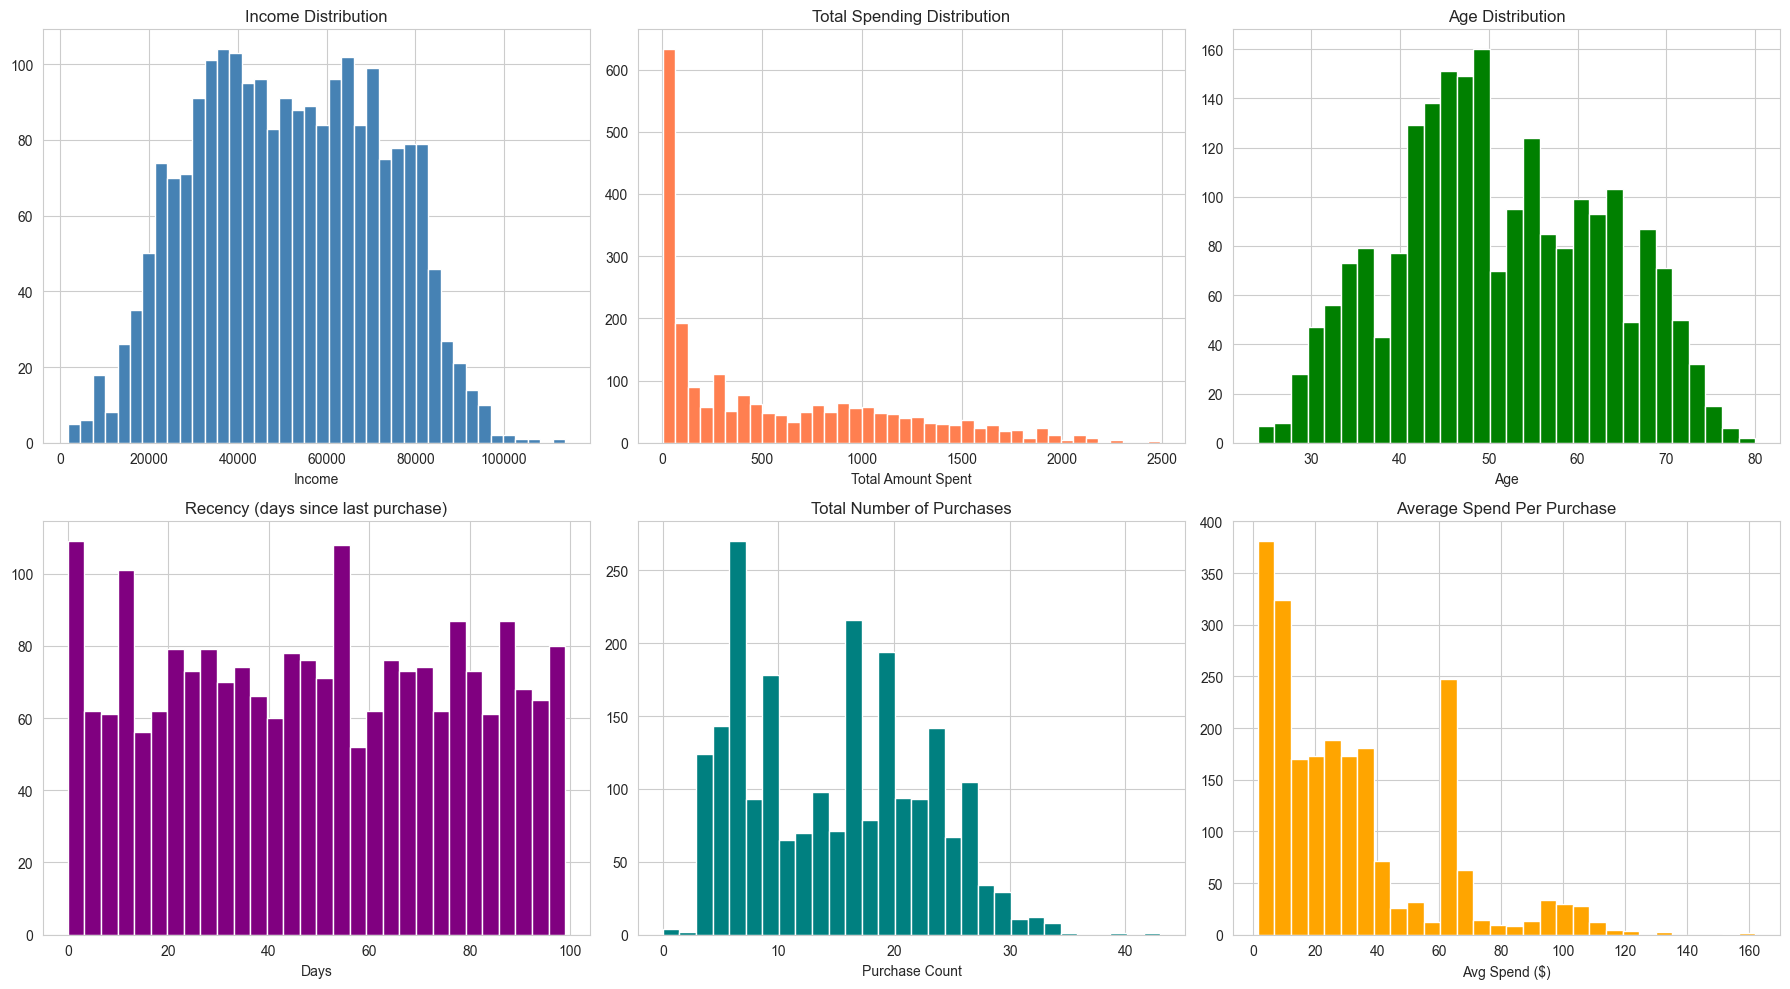

In [6]:
# Distribution of key variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(df['Income'], bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Income Distribution')
axes[0, 0].set_xlabel('Income')

axes[0, 1].hist(df['MntTotal'], bins=40, color='coral', edgecolor='white')
axes[0, 1].set_title('Total Spending Distribution')
axes[0, 1].set_xlabel('Total Amount Spent')

axes[0, 2].hist(df['Age'], bins=30, color='green', edgecolor='white')
axes[0, 2].set_title('Age Distribution')
axes[0, 2].set_xlabel('Age')

axes[1, 0].hist(df['Recency'], bins=30, color='purple', edgecolor='white')
axes[1, 0].set_title('Recency (days since last purchase)')
axes[1, 0].set_xlabel('Days')

axes[1, 1].hist(df['TotalPurchases'], bins=30, color='teal', edgecolor='white')
axes[1, 1].set_title('Total Number of Purchases')
axes[1, 1].set_xlabel('Purchase Count')

axes[1, 2].hist(df['AvgSpendPerPurchase'], bins=30, color='orange', edgecolor='white')
axes[1, 2].set_title('Average Spend Per Purchase')
axes[1, 2].set_xlabel('Avg Spend ($)')

plt.tight_layout()
plt.show()

In [7]:
# Average metrics by marital status
marital_stats = df.groupby('MaritalStatus')[['Income', 'MntTotal', 'TotalPurchases', 'Age']].mean().round(2)
print('Average metrics by Marital Status:')
display(marital_stats)

print('\nAverage metrics by Education Level:')
edu_stats = df.groupby('EducationLevel')[['Income', 'MntTotal', 'TotalPurchases', 'Age']].mean().round(2)
display(edu_stats)

Average metrics by Marital Status:


,Income,MntTotal,TotalPurchases,Age
MaritalStatus,,,,
Divorced,52465.12,569.05,15.34,53.47
Married,51350.51,546.65,14.91,50.43
Single,51009.62,569.27,14.35,48.23
Together,51553.20,564.35,14.90,52.18
Widow,56481.55,672.11,16.63,61.24



Average metrics by Education Level:


,Income,MntTotal,TotalPurchases,Age
EducationLevel,,,,
2n Cycle,47625.33,452.27,14.03,47.21
Basic,20306.26,58.96,7.02,42.54
Graduation,51984.01,570.94,15.01,50.38
Master,52629.58,571.00,14.93,53.06
PhD,55220.58,640.47,15.82,53.85


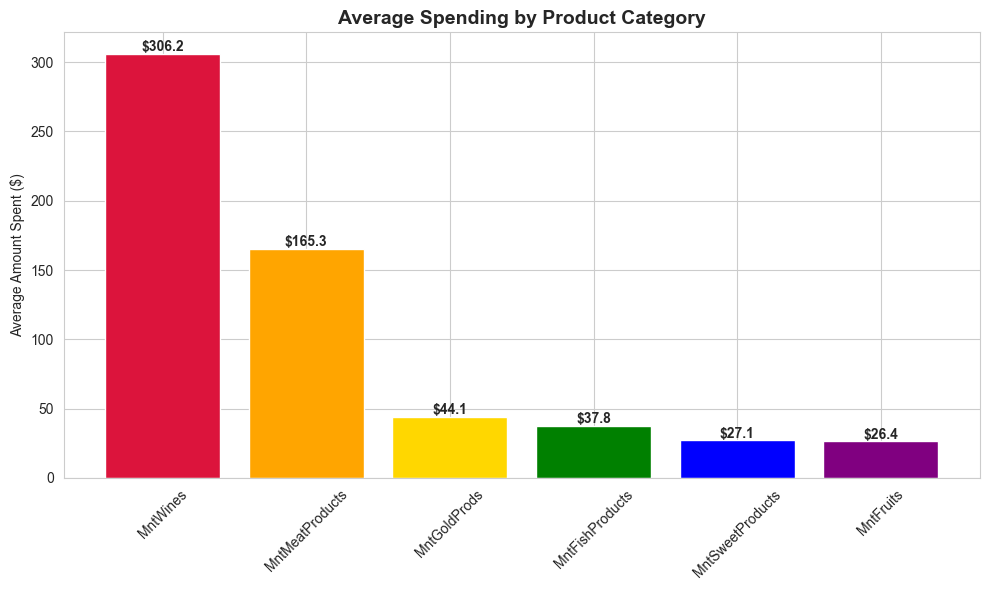

In [8]:
# Product category spending breakdown
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
product_means = df[product_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(product_means.index, product_means.values, color=['crimson', 'orange', 'gold', 'green', 'blue', 'purple'])
plt.title('Average Spending by Product Category', fontsize=14, fontweight='bold')
plt.ylabel('Average Amount Spent ($)')
plt.xticks(rotation=45)
for bar, val in zip(bars, product_means.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'${val:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Customer Segmentation with K-Means Clustering

We select relevant features for segmentation: income, spending patterns, purchase behavior, and customer demographics.

In [9]:
# Select features for clustering
cluster_features = [
    'Income', 'Recency', 'MntTotal', 'MntRegularProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Age', 'TotalChildren', 'AcceptedCmpOverall'
]

X = df[cluster_features].copy()

print(f'Features used for clustering ({len(cluster_features)}):')
for f in cluster_features:
    print(f'  - {f}')
print(f'\nShape of feature matrix: {X.shape}')

Features used for clustering (12):
  - Income
  - Recency
  - MntTotal
  - MntRegularProds
  - NumDealsPurchases
  - NumWebPurchases
  - NumCatalogPurchases
  - NumStorePurchases
  - NumWebVisitsMonth
  - Age
  - TotalChildren
  - AcceptedCmpOverall

Shape of feature matrix: (2205, 12)


In [10]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature scaling completed.')
print(f'Scaled data shape: {X_scaled.shape}')

Feature scaling completed.
Scaled data shape: (2205, 12)


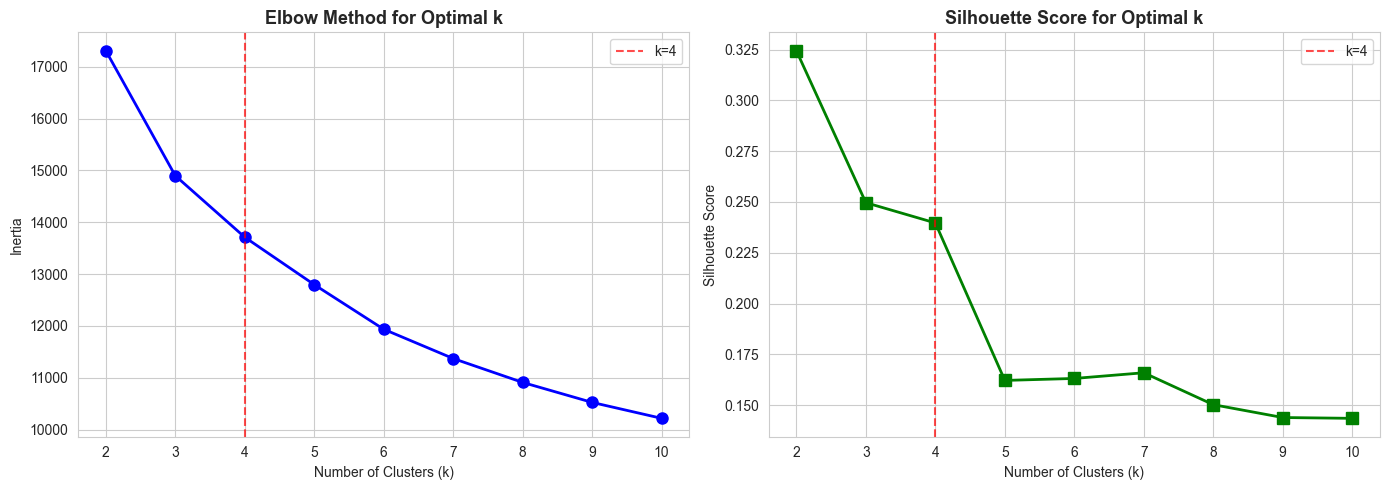

k=2: Inertia=17310.28, Silhouette=0.3244
k=3: Inertia=14898.39, Silhouette=0.2496
k=4: Inertia=13712.06, Silhouette=0.2397
k=5: Inertia=12797.05, Silhouette=0.1622
k=6: Inertia=11936.29, Silhouette=0.1631
k=7: Inertia=11371.76, Silhouette=0.1659
k=8: Inertia=10910.44, Silhouette=0.1502
k=9: Inertia=10525.07, Silhouette=0.1439
k=10: Inertia=10217.74, Silhouette=0.1435


In [11]:
# Determine optimal k using Elbow Method and Silhouette Score
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='b', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='r', linestyle='--', alpha=0.7, label='k=4')
axes[0].legend()

axes[1].plot(k_range, sil_scores, marker='s', color='g', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score for Optimal k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='r', linestyle='--', alpha=0.7, label='k=4')
axes[1].legend()

plt.tight_layout()
plt.show()

for k, inert, sil in zip(k_range, inertias, sil_scores):
    print(f'k={k}: Inertia={inert:.2f}, Silhouette={sil:.4f}')

### Applying K-Means with optimal k

In [12]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(X_scaled)

print(f'Customer segments assigned. Distribution:')
print(df['Segment'].value_counts().sort_index())

Customer segments assigned. Distribution:
Segment
0     199
1     536
2     466
3    1004
Name: count, dtype: int64


In [13]:
# Map segment numbers to descriptive names
segment_names = {
    0: 'Premium High-Spenders',
    1: 'Budget-Conscious Shoppers',
    2: 'Occasional Buyers',
    3: 'Loyal Regulars'
}
df['SegmentName'] = df['Segment'].map(segment_names)

print('Segment mapping:')
for k, v in segment_names.items():
    print(f'  {k} -> {v}')

Segment mapping:
  0 -> Premium High-Spenders
  1 -> Budget-Conscious Shoppers
  2 -> Occasional Buyers
  3 -> Loyal Regulars


### Visualizing Segments with PCA

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(4)}')
print(f'Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}')

Explained variance ratio: [0.4374 0.1377]
Total variance explained by 2 components: 57.51%


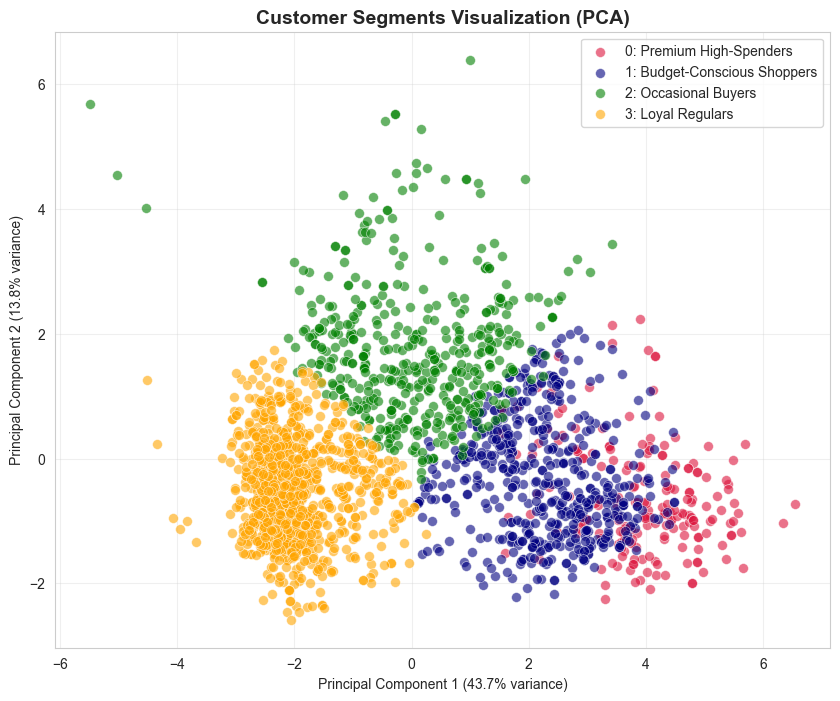

In [15]:
plt.figure(figsize=(10, 8))
colors = ['crimson', 'navy', 'green', 'orange']

for seg in sorted(df['Segment'].unique()):
    mask = df['Segment'] == seg
    plt.scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                c=colors[seg], label=f'{seg}: {segment_names[seg]}',
                alpha=0.6, s=50, edgecolors='w', linewidth=0.5)

plt.title('Customer Segments Visualization (PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Segment Profile Analysis

Analyzing the characteristics of each customer segment.

In [16]:
# Segment-wise averages
seg_analysis = df.groupby('SegmentName').agg({
    'Income': 'mean',
    'Age': 'mean',
    'MntTotal': 'mean',
    'Recency': 'mean',
    'TotalPurchases': 'mean',
    'NumWebPurchases': 'mean',
    'NumCatalogPurchases': 'mean',
    'NumStorePurchases': 'mean',
    'NumDealsPurchases': 'mean',
    'NumWebVisitsMonth': 'mean',
    'TotalChildren': 'mean',
    'AcceptedCmpOverall': 'mean',
    'AvgSpendPerPurchase': 'mean'
}).round(2)

print('Segment Profiles:')
display(seg_analysis)

Segment Profiles:


,Income,Age,MntTotal,Recency,TotalPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalChildren,AcceptedCmpOverall,AvgSpendPerPurchase
SegmentName,,,,,,,,,,,,,
Budget-Conscious Shoppers,70977.96,53.68,1055.57,49.76,20.61,5.24,5.29,8.60,1.49,3.07,0.40,0.14,53.75
Loyal Regulars,34427.35,48.50,80.44,48.90,7.73,2.07,0.55,3.23,1.88,6.38,1.21,0.09,10.01
Occasional Buyers,54052.43,54.22,590.48,48.53,20.98,6.54,2.59,7.13,4.73,6.55,1.33,0.24,33.08
Premium High-Spenders,80547.96,49.89,1603.91,48.66,21.31,5.57,6.22,8.38,1.14,3.36,0.23,1.96,79.49


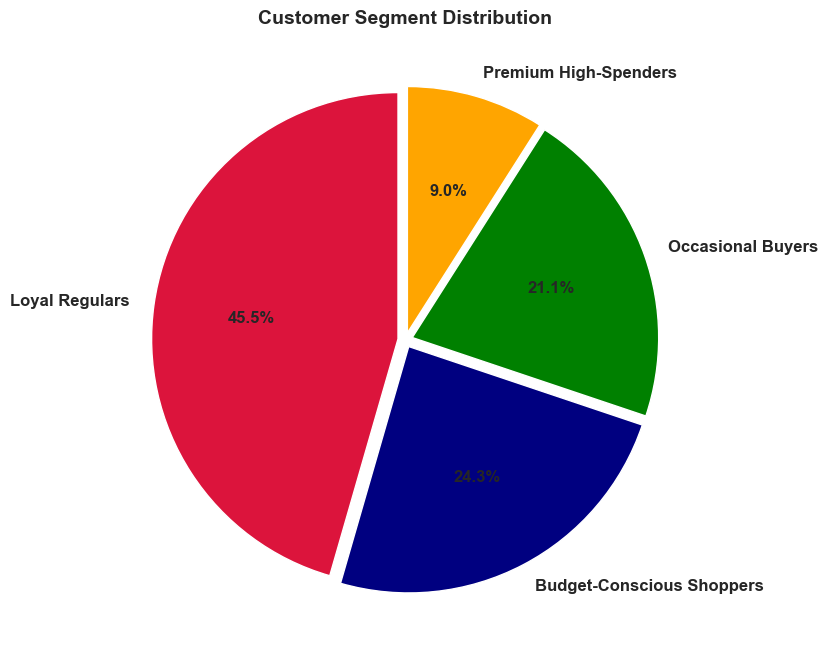

In [17]:
# Segment size
seg_counts = df['SegmentName'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=[0.03]*optimal_k,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.show()

### Key Segment Characteristics Comparison

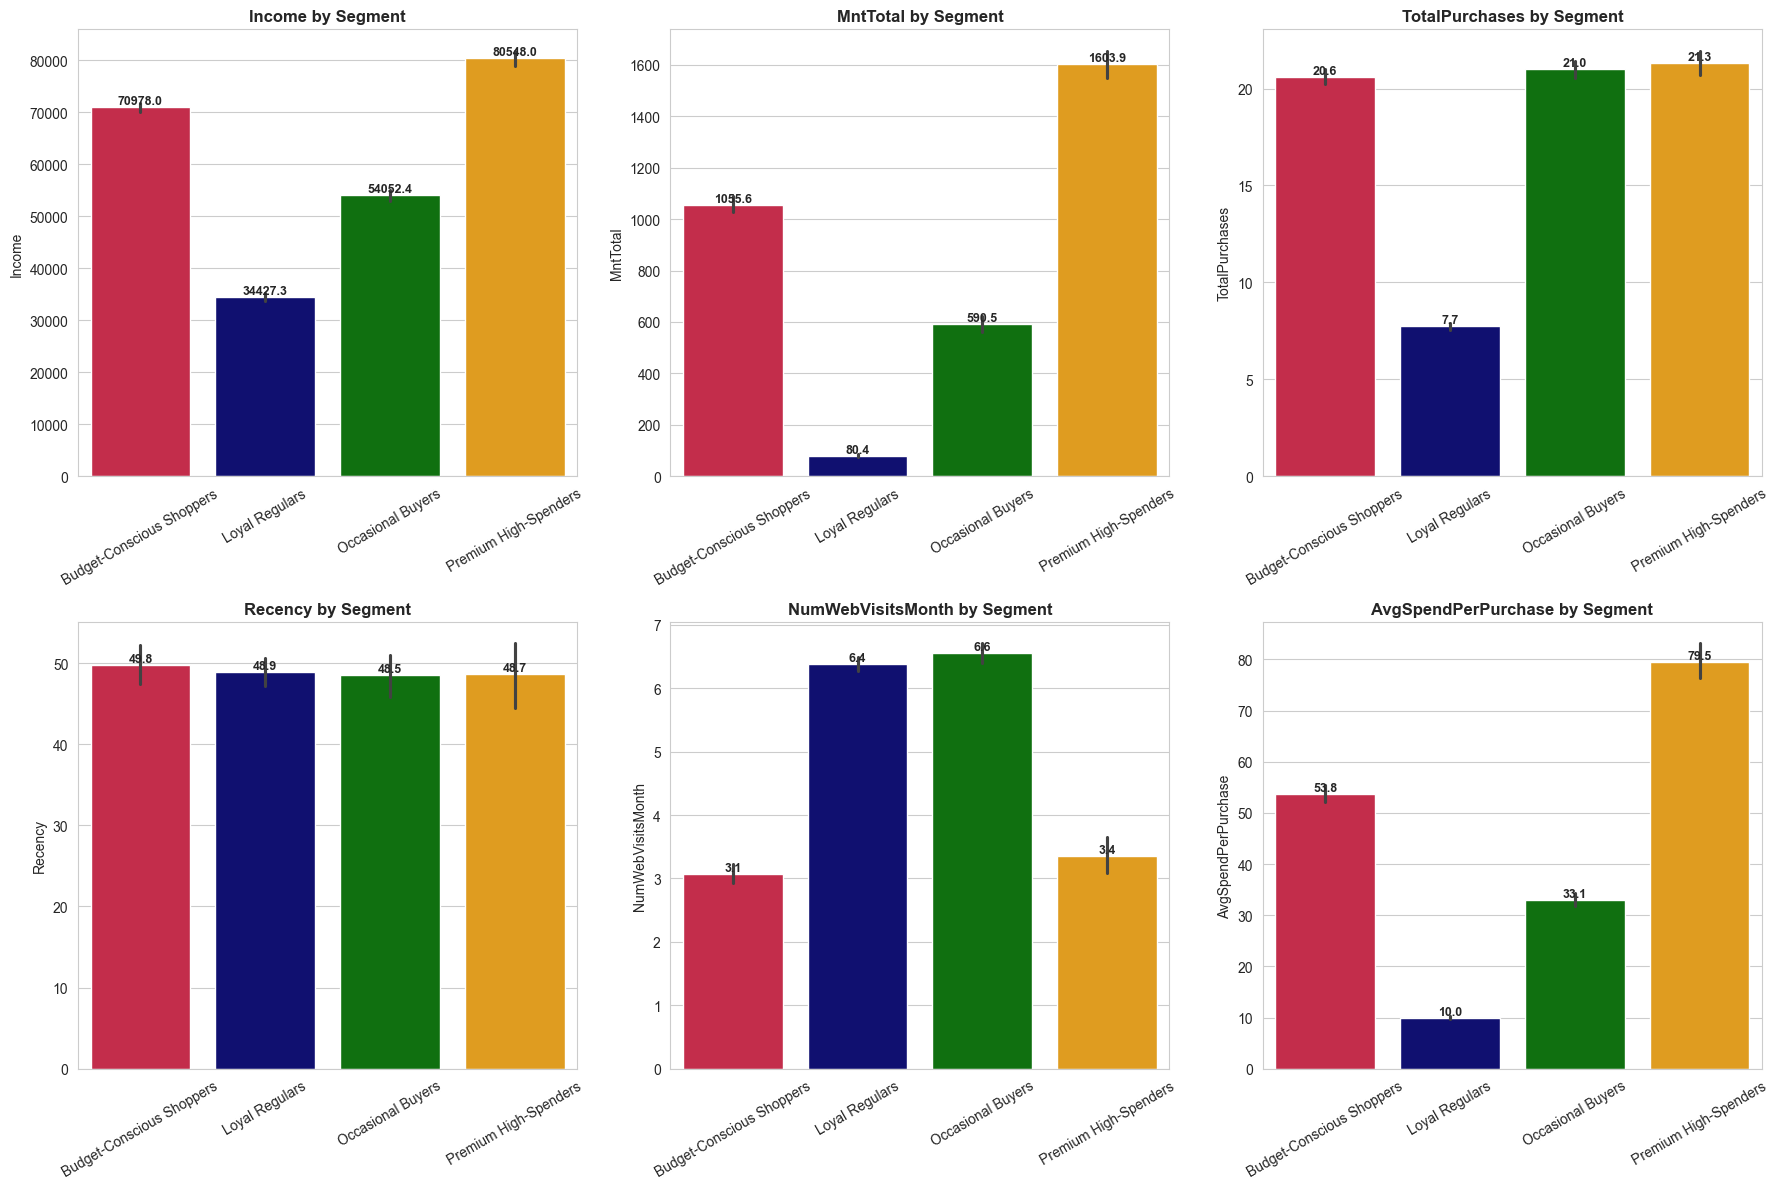

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

metrics = ['Income', 'MntTotal', 'TotalPurchases', 'Recency', 'NumWebVisitsMonth', 'AvgSpendPerPurchase']

for idx, metric in enumerate(metrics):
    row, col = divmod(idx, 3)
    sns.barplot(data=df, x='SegmentName', y=metric, hue='SegmentName', ax=axes[row, col], palette=colors, legend=False)
    axes[row, col].set_title(f'{metric} by Segment', fontweight='bold')
    axes[row, col].set_xlabel('')
    axes[row, col].tick_params(axis='x', rotation=30)
    for p in axes[row, col].patches:
        axes[row, col].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

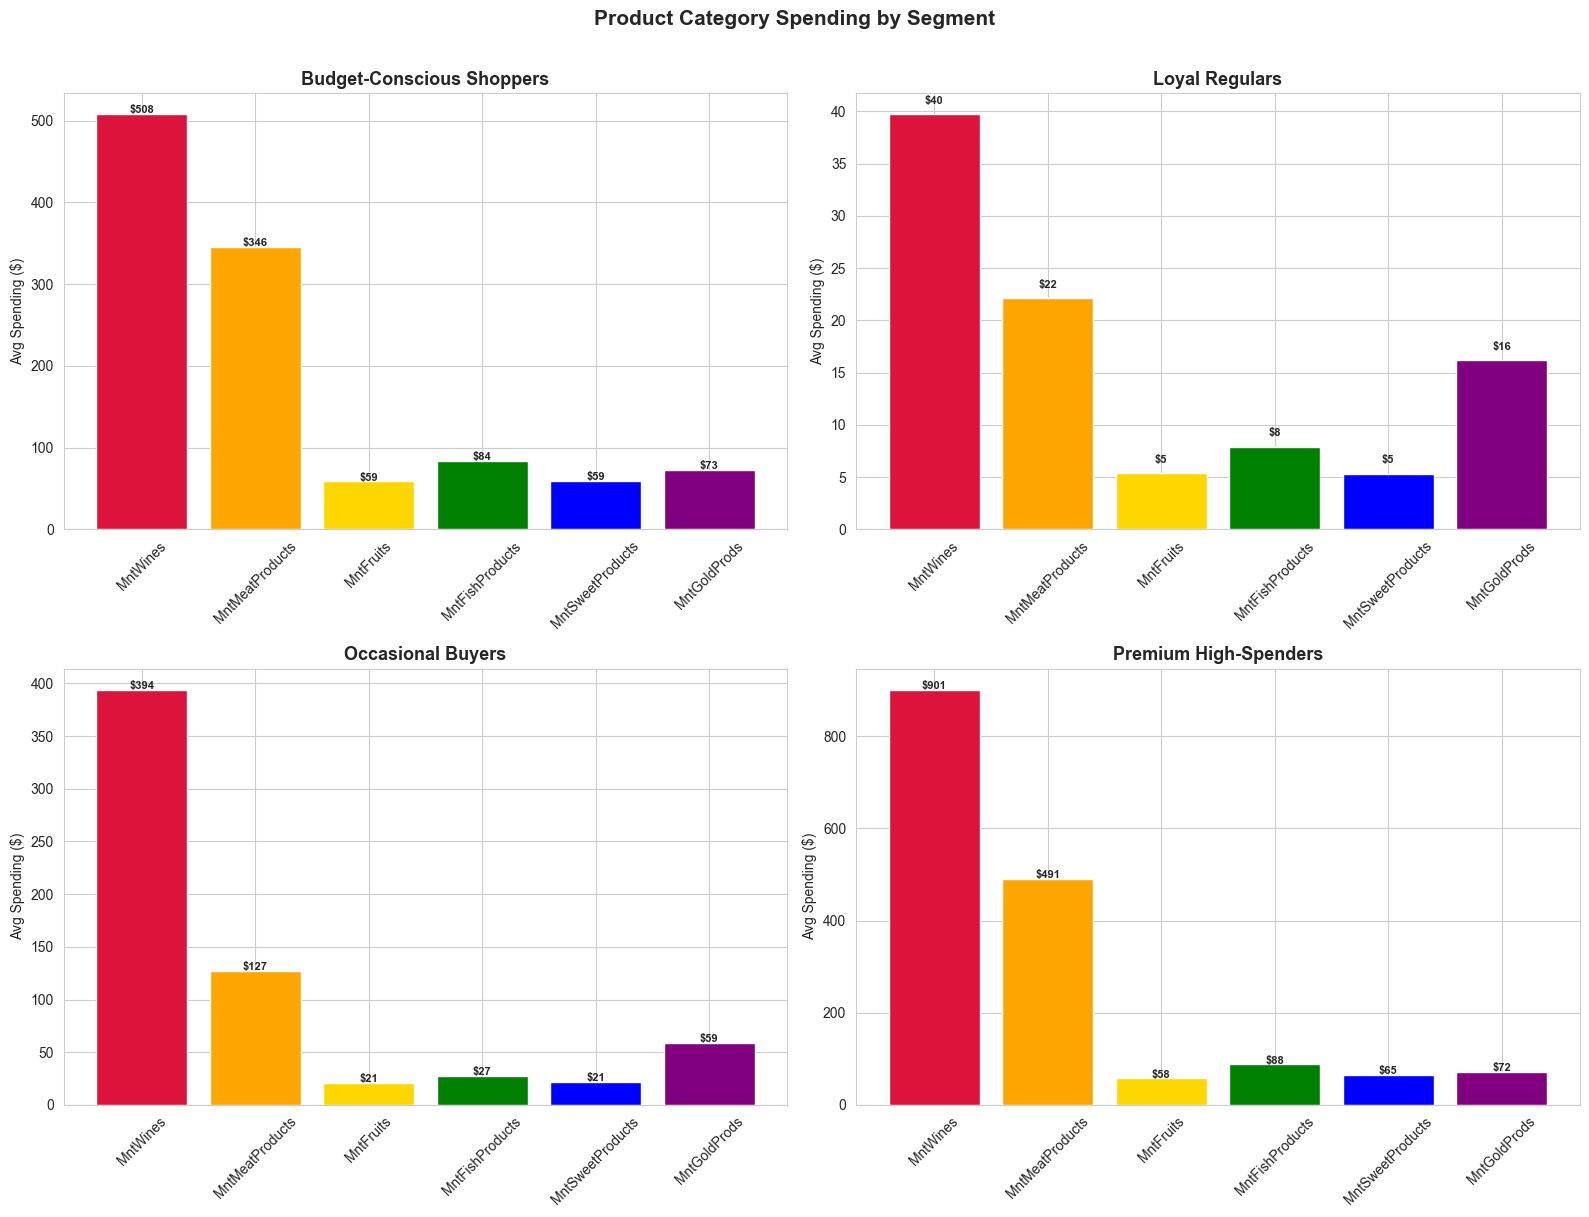

In [19]:
# Spending breakdown by product category per segment
product_cols = ['MntWines', 'MntMeatProducts', 'MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
seg_product = df.groupby('SegmentName')[product_cols].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, seg in enumerate(seg_product.index):
    ax = axes[i]
    vals = seg_product.loc[seg]
    bars = ax.bar(vals.index, vals.values, color=['crimson', 'orange', 'gold', 'green', 'blue', 'purple'])
    ax.set_title(f'{seg}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Avg Spending ($)')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'${val:.0f}',
                ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Product Category Spending by Segment', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Insights and Recommendations

In [20]:
seg_pct = df['SegmentName'].value_counts(normalize=True).mul(100).round(1)

seg_stats = df.groupby('SegmentName').agg(
    AvgIncome=('Income', 'mean'),
    AvgSpend=('MntTotal', 'mean'),
    AvgRecency=('Recency', 'mean')
).round(1)

key_behavior = {
    'Premium High-Spenders': 'High income, high spending, premium products',
    'Budget-Conscious Shoppers': 'Deal-seeking, moderate spend, value-driven',
    'Occasional Buyers': 'Infrequent purchases, moderate spend, re-engagement opportunity',
    'Loyal Regulars': 'Frequent visits, steady spend, loyal customers'
}

summary = seg_stats.assign(
    PercentCustomers=seg_pct,
    KeyBehavior=[key_behavior.get(seg, '') for seg in seg_stats.index]
)[['PercentCustomers', 'AvgIncome', 'AvgSpend', 'AvgRecency', 'KeyBehavior']]

display(summary.sort_values('PercentCustomers', ascending=False))

,PercentCustomers,AvgIncome,AvgSpend,AvgRecency,KeyBehavior
SegmentName,,,,,
Loyal Regulars,45.5,34427.3,80.4,48.9,"Frequent visits, steady spend, loyal customers"
Budget-Conscious Shoppers,24.3,70978.0,1055.6,49.8,"Deal-seeking, moderate spend, value-driven"
Occasional Buyers,21.1,54052.4,590.5,48.5,"Infrequent purchases, moderate spend, re-engag..."
Premium High-Spenders,9.0,80548.0,1603.9,48.7,"High income, high spending, premium products"


### Strategic Recommendations

**1. Premium High-Spenders (High Value)**
- Offer exclusive loyalty programs and VIP perks
- Cross-sell premium products (wine, meat) with personalized recommendations
- Send early access to new collections and catalog previews
- Target with high-end catalog mailings

**2. Budget-Conscious Shoppers (Deal Seekers)**
- Promote discount deals, bundle offers, and BOGO campaigns
- Increase email/web engagement with coupons
- Encourage upsell with 'spend X get Y off' promotions
- Use social media and web ads to drive repeat purchases

**3. Occasional Buyers (Dormant / At Risk)**
- Re-engagement campaigns with 'We miss you' offers
- Win-back discounts and limited-time promotions
- Analyze why they churned (complaints, recency) and address pain points
- Simplify the purchase funnel to reduce friction

**4. Loyal Regulars (Steady Performers)**
- Rewards program to increase spend per visit
- Introduce subscription/premium membership
- Recommend complementary products based on purchase history
- Solicit reviews and referrals to acquire similar customers

### Next Steps
- Implement targeted marketing campaigns per segment
- Track segment migration over time (are customers moving up?)
- A/B test different marketing strategies for each segment
- Periodically re-cluster as new customer data arrives

In [21]:
# Final segment counts
print('Final Customer Segment Distribution:')
print(df['SegmentName'].value_counts())
print(f'\nPercentage:')
print(df['SegmentName'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Final Customer Segment Distribution:
SegmentName
Loyal Regulars               1004
Budget-Conscious Shoppers     536
Occasional Buyers             466
Premium High-Spenders         199
Name: count, dtype: int64

Percentage:
SegmentName
Loyal Regulars               45.5%
Budget-Conscious Shoppers    24.3%
Occasional Buyers            21.1%
Premium High-Spenders         9.0%
Name: proportion, dtype: object
